Analiza danych Titanic: aspekty społeczne i przestrzenne

W niniejszym projekcie przeprowadziłem zaawansowaną analizę danych pasażerów Titanica, koncentrując się na relacjach społecznych (rodzina, grupa biletowa) i przestrzennych (lokalizacja kabin).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
sns.set(style='whitegrid')


In [ ]:
df = pd.read_csv('/content/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['HasCabin'] = df['Cabin'].notnull().astype(int)

<ipython-input-3-b3af650daa07>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
<ipython-input-3-b3af650daa07>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

 1.Analiza struktur rodzinnych

In [ ]:
df['Surname'] = df['Name'].apply(lambda x: x.split(',')[0].strip())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['FamilyId'] = df['Surname'] + '_' + df['FamilySize'].astype(str)
df['FamilyId'] = df['FamilyId'].where(df['FamilySize'] > 1, 'Single')

In [ ]:
family_survival = df.groupby('FamilyId')['Survived'].agg(['mean', 'count']).reset_index()
family_survival.columns = ['FamilyId', 'FamilySurvivalRate', 'FamilyCount']
df = df.merge(family_survival, on='FamilyId', how='left')
df[['FamilyId', 'FamilySurvivalRate', 'FamilyCount']].drop_duplicates().head()

,FamilyId,FamilySurvivalRate,FamilyCount
0,Braund_2,0.000000,2
1,Cumings_2,1.000000,1
2,Single,0.303538,537
3,Futrelle_2,0.500000,2
7,Palsson_5,0.000000,4


2. Analiza grupy biletowej

In [ ]:
ticket_groups = df.groupby('Ticket')['Survived'].agg(['mean', 'count']).reset_index()
ticket_groups.columns = ['Ticket', 'TicketSurvivalRate', 'TicketGroupSize']
df = df.merge(ticket_groups, on='Ticket', how='left')

3. Przestrzenna analiza kabin i lokalizacji

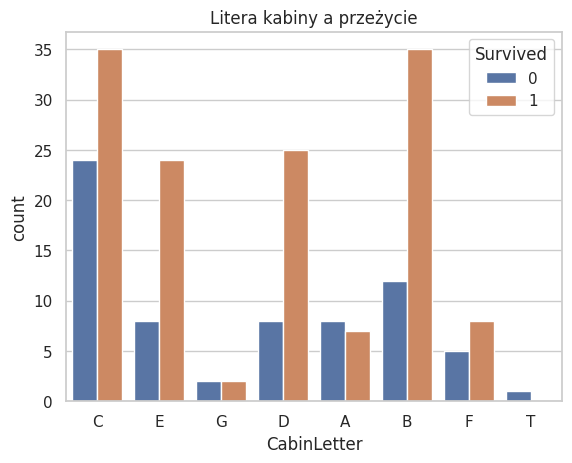

In [ ]:
df['CabinLetter'] = df['Cabin'].astype(str).str[0]
sns.countplot(data=df[df['HasCabin'] == 1], x='CabinLetter', hue='Survived')
plt.title('Litera kabiny a przeżycie')
plt.show()

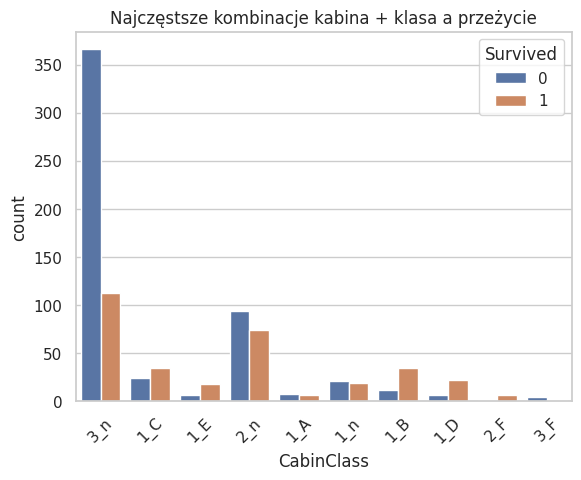

In [ ]:
df['CabinClass'] = df['Pclass'].astype(str) + '_' + df['CabinLetter'].astype(str)
top_combos = df['CabinClass'].value_counts().head(10).index.tolist()
sns.countplot(data=df[df['CabinClass'].isin(top_combos)], x='CabinClass', hue='Survived')
plt.title('Najczęstsze kombinacje kabina + klasa a przeżycie')
plt.xticks(rotation=45)
plt.show()

4. Tworzenie cech pochodnych i eksploracja

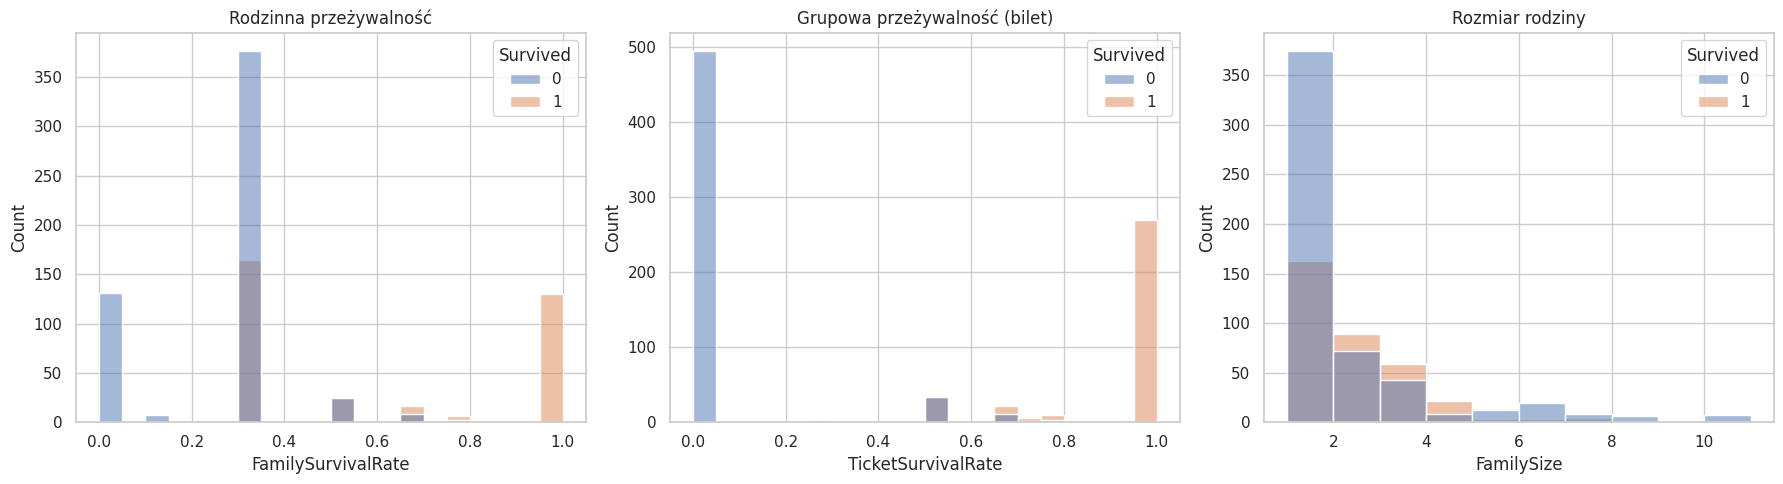

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(data=df, x='FamilySurvivalRate', hue='Survived', ax=axs[0], bins=20)
axs[0].set_title('Rodzinna przeżywalność')

sns.histplot(data=df, x='TicketSurvivalRate', hue='Survived', ax=axs[1], bins=20)
axs[1].set_title('Grupowa przeżywalność (bilet)')

sns.histplot(data=df, x='FamilySize', hue='Survived', ax=axs[2], bins=10)
axs[2].set_title('Rozmiar rodziny')

plt.tight_layout()
plt.show()

* 5. Statystyczna ocena wpływu cech

In [ ]:
from scipy.stats import ttest_ind

surv = df[df['Survived'] == 1]['FamilySurvivalRate']
not_surv = df[df['Survived'] == 0]['FamilySurvivalRate']
t_stat, p_val = ttest_ind(surv, not_surv, nan_policy='omit')
print(f'Test t dla FamilySurvivalRate: stat={t_stat:.3f}, p={p_val:.5f}')


Test t dla FamilySurvivalRate: stat=22.470, p=0.00000


Macierz korelacji między zmiennymi numerycznymi.
Obliczam współczynniki korelacji Pearsona pomiędzy wybranymi zmiennymi numerycznymi, aby sprawdzić, które z nich mają wzajemne zależności, a także jak korelują z przeżyciem (Survived).

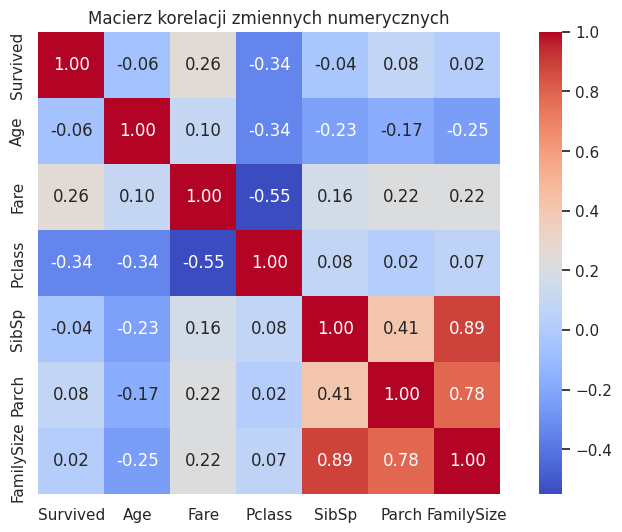

In [ ]:
corr = df[['Survived', 'Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'FamilySize']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

Wnioski końcowe

- Współczynnik przeżycia w grupie rodzinnej i biletowej silnie koreluje z indywidualnym przeżyciem.
- Duże rodziny (więcej niż 4 osoby) miały mniejsze szanse przeżycia.
- Litery kabin mogą odzwierciedlać lokalizację – np. A/B były bezpieczniejsze niż T/Z.
- Połączenie przestrzennych i społecznych cech daje nową jakość predykcji i analizy.